In [6]:
import torch
import torch.nn.functional as F
from torch.autograd import Variable

N = 10
M = 20
# 创建两个张量
tensor_N = torch.randn((N, 3), requires_grad=True)
tensor_M = torch.randn((M, 3), requires_grad=True)

# 进行concatenation
concatenated_tensor = torch.cat((tensor_N, tensor_M))
print(f"after concatenated:{concatenated_tensor.size()}")

# 进行截取
sliced_tensor = concatenated_tensor[15]

# 假设有一个损失函数
loss = torch.mean(sliced_tensor)

# 反向传播
loss.backward()

# 输出梯度
print("梯度 tensor_N:", tensor_N.grad)
print("梯度 tensor_M:", tensor_M.grad)

after concatenated:torch.Size([30, 3])
梯度 tensor_N: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
梯度 tensor_M: tensor([[0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000]])


In [1]:
from pytorch3d.ops import sample_points_from_meshes
from pytorch3d.structures import Meshes
from pytorch3d.structures import join_meshes_as_batch
from pytorch3d.utils import ico_sphere

import matplotlib.pyplot as plt

In [8]:
def plot_pointcloud(mesh, title=""):
    # Sample points uniformly from the surface of the mesh.
    points = sample_points_from_meshes(mesh, 500)
    x, y, z = points.clone().detach().cpu().squeeze().unbind(1)    
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter3D(x, z, -y)
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_zlabel('y')
    ax.set_title(title)
    ax.view_init(190, 30)
    plt.show()

torch.Size([12, 3])
torch.Size([20, 3])


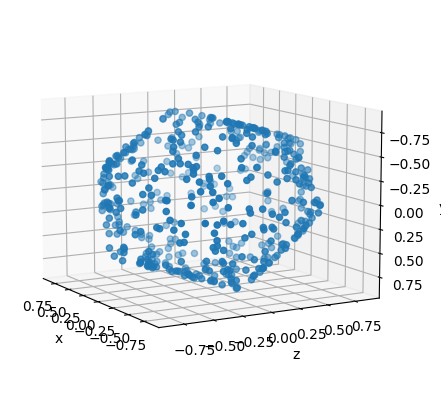

In [9]:
mSphere = ico_sphere(0)
print(mSphere)
print(mSphere.verts_packed().size())
print(mSphere.faces_list()[0].size())
plot_pointcloud(mSphere)